[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/da380/PartIIStatistics/blob/main/notebooks/06_correlation_and_regression.ipynb)

# 6. Correlation and regression

**What you should get out of this notebook**

- Define and compute the correlation coefficient, and know what it does and does not measure.
- Understand the relation between correlation and the least-squares line, and why there are two regression lines.
- Use rank correlation when the relationship is not linear or the data have outliers.
- Recognise the traps: correlation is not causation, trending series correlate spuriously, regression to the mean, and errors in $x$ bias the slope.

**Tools introduced**

- `np.corrcoef`, `stats.pearsonr` and its `.confidence_interval()`
- `stats.spearmanr`, `stats.kendalltau`
- `stats.linregress`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

rng = np.random.default_rng(1)          # random number generator with a fixed seed
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
DATA = "https://raw.githubusercontent.com/da380/PartIIStatistics/main/data/"

## The correlation coefficient

For paired data $(x_i, y_i)$ the **sample covariance** and **Pearson correlation coefficient** are

$$
s_{xy} = \frac{1}{n-1}\sum_i (x_i - \bar{x})(y_i - \bar{y}), \qquad
r = \frac{s_{xy}}{s_x s_y} = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i - \bar{x})^2 \sum_i (y_i - \bar{y})^2}} .
$$

The coefficient $r$ lies between $-1$ and $1$. It is $\pm 1$ when the points lie exactly on a straight line, and 0 when there is no *linear* association. It is dimensionless and unchanged by rescaling either variable. Three things it is important to understand about $r$:

- It measures **linear** association only. A perfect but curved relationship can have $r$ near zero.
- It says nothing about the **slope**. A shallow line and a steep line can both have $r = 1$.
- It is sensitive to **outliers**: a single wild point can create or destroy a correlation.

The connection to Notebook 5 is that the least-squares slope of $y$ on $x$ is

$$
\hat{a} = r\,\frac{s_y}{s_x},
$$

and $r^2$ is the fraction of the variance of $y$ that is accounted for by the line. `stats.pearsonr` returns $r$ together with a p-value for the null hypothesis of zero correlation and, through its `confidence_interval` method, a confidence interval for $r$.

r = 0.901,  95% CI [0.876, 0.921],  p = 8.1e-100
r² = 0.811: the line explains 81% of the variance in waiting time
slope = 10.73 min per min;  check r * s_w / s_d = 10.73


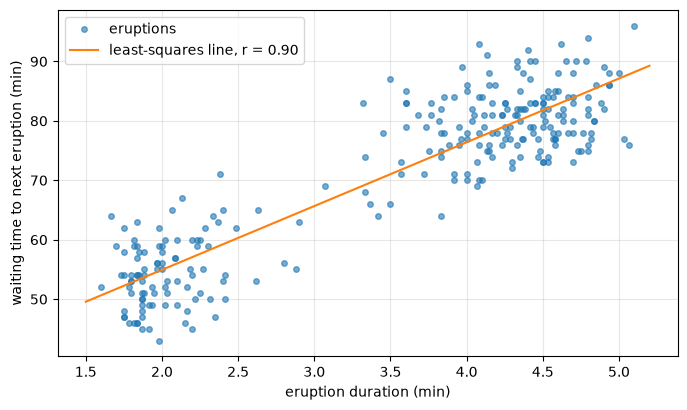

In [ ]:
faithful = pd.read_csv(DATA + "old_faithful.csv")
d = faithful["eruptions"].to_numpy()
w = faithful["waiting"].to_numpy()

res = stats.pearsonr(d, w)
ci = res.confidence_interval(0.95)
print(f"r = {res.statistic:.3f},  95% CI [{ci.low:.3f}, {ci.high:.3f}],  p = {res.pvalue:.1e}")
print(f"r² = {res.statistic**2:.3f}: the line explains {100*res.statistic**2:.0f}% of the variance in waiting time")

lr = stats.linregress(d, w)
print(f"slope = {lr.slope:.2f} min per min;  check r * s_w / s_d = {res.statistic * w.std(ddof=1) / d.std(ddof=1):.2f}")

fig, ax = plt.subplots()
ax.plot(d, w, "o", ms=4, alpha=0.6, label="eruptions")
xx = np.linspace(1.5, 5.2, 50)
ax.plot(xx, lr.intercept + lr.slope*xx, "C1", label=f"least-squares line, r = {res.statistic:.2f}")
ax.set(xlabel="eruption duration (min)", ylabel="waiting time to next eruption (min)"); ax.legend()
plt.show()

The duration of an eruption is a good predictor of the wait until the next one, which is what the park rangers use.

### Two regression lines

Regressing $y$ on $x$ minimises the vertical distances of the points from the line; it answers "what is the best prediction of $y$ given $x$?" Regressing $x$ on $y$ minimises horizontal distances and answers the opposite question. These are different lines unless $|r| = 1$. Neither is "the" line through the cloud of points; that would be the major axis of the scatter, which is a third line again (and what York's method of Notebook 5 tends to when $x$ and $y$ have comparable errors). Which line you want depends on what you are trying to do.

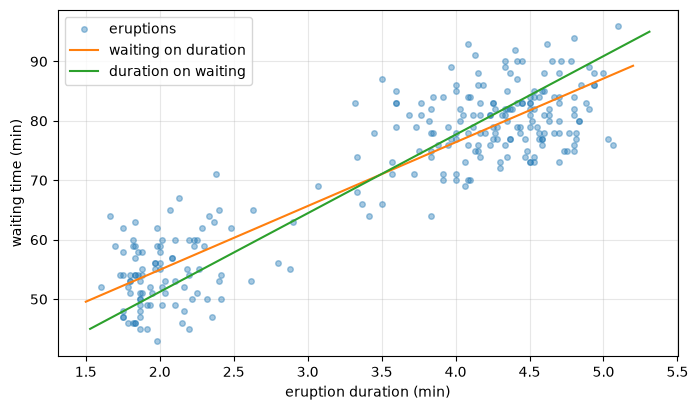

slope of waiting on duration: 10.73;  1 / (slope of duration on waiting): 13.22


In [ ]:
lr_yx = stats.linregress(d, w)          # waiting on duration
lr_xy = stats.linregress(w, d)          # duration on waiting

fig, ax = plt.subplots()
ax.plot(d, w, "o", ms=4, alpha=0.4, label="eruptions")
ax.plot(xx, lr_yx.intercept + lr_yx.slope*xx, "C1", label="waiting on duration")
ww = np.linspace(45, 95, 50)
ax.plot(lr_xy.intercept + lr_xy.slope*ww, ww, "C2", label="duration on waiting")
ax.set(xlabel="eruption duration (min)", ylabel="waiting time (min)"); ax.legend()
plt.show()
print(f"slope of waiting on duration: {lr_yx.slope:.2f};  1 / (slope of duration on waiting): {1/lr_xy.slope:.2f}")

## Anscombe's quartet: why you must plot the data

Four small data sets constructed by Anscombe in 1973 have the same means, the same variances, the same correlation coefficient and the same least-squares line. They could not be more different.

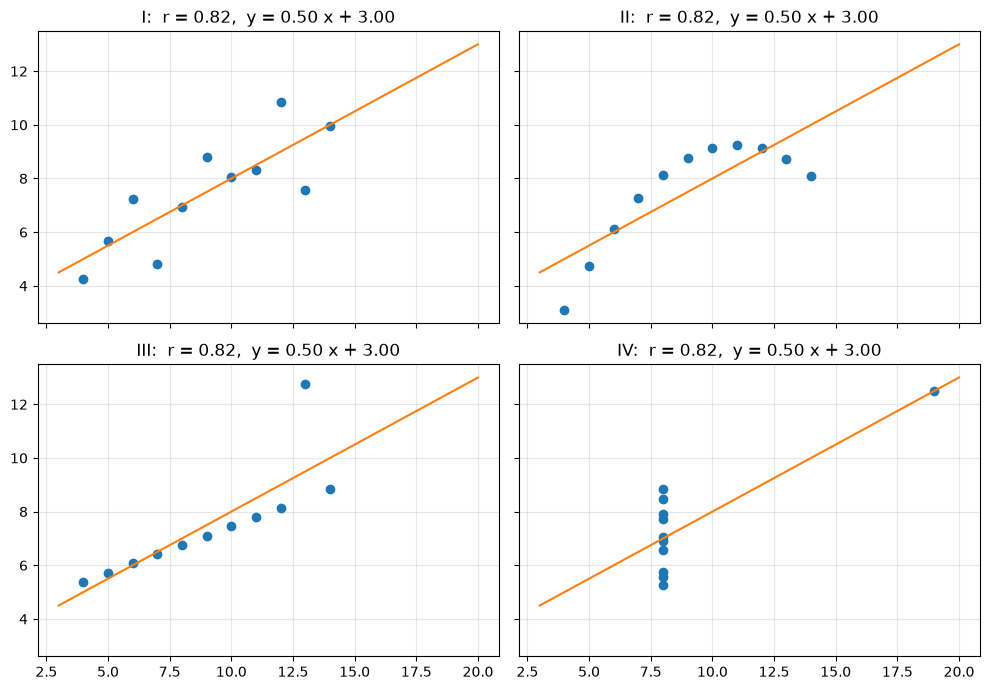

In [ ]:
x123 = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], dtype=float)
anscombe = {
    "I":   (x123, np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68])),
    "II":  (x123, np.array([9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74])),
    "III": (x123, np.array([7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73])),
    "IV":  (np.array([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8], dtype=float),
            np.array([6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])),
}
fig, ax = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for a, (name, (xa, ya)) in zip(ax.ravel(), anscombe.items()):
    lr = stats.linregress(xa, ya)
    a.plot(xa, ya, "o")
    xx = np.linspace(3, 20, 10); a.plot(xx, lr.intercept + lr.slope*xx, "C1")
    a.set_title(f"{name}:  r = {lr.rvalue:.2f},  y = {lr.slope:.2f} x + {lr.intercept:.2f}")
plt.tight_layout(); plt.show()

Set I is what the summary statistics suggest. Set II is a perfect curve, for which a straight line is the wrong model. Set III is a perfect line plus one outlier, which has pulled the fitted line away from the other ten points. In set IV a single point creates the entire correlation; without it $x$ does not vary at all. A correlation coefficient, or a fitted slope, is meaningless until you have looked at the scatter plot.

## Rank correlation

**Spearman's rank correlation** $\rho$ is the Pearson correlation of the *ranks* of the data (the position of each value when sorted). It measures whether the relationship is **monotonic** rather than linear, and because ranks are bounded it is far less affected by outliers. **Kendall's $\tau$** is similar, based on counting concordant pairs, and has a more direct interpretation but is less common. Both are non-parametric: their p-values do not assume normality. Below, one outlier added to twenty weakly related points changes Pearson's $r$ dramatically and Spearman's $\rho$ hardly at all.

without outlier : Pearson r = -0.20 (p = 0.400);  Spearman ρ = -0.16 (p = 0.490);  Kendall τ = -0.12
with outlier    : Pearson r =  0.64 (p = 0.002);  Spearman ρ = -0.01 (p = 0.982);  Kendall τ = -0.01


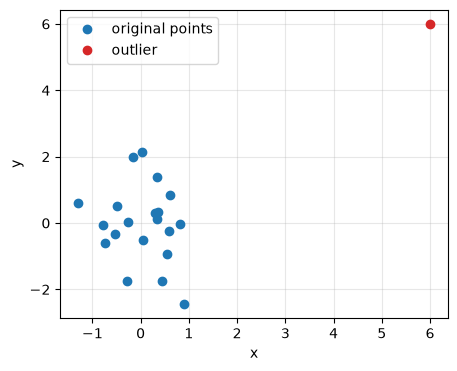

In [ ]:
xs = stats.norm().rvs(20, random_state=rng)
ys = 0.3*xs + stats.norm().rvs(20, random_state=rng)
xo, yo = np.append(xs, 6), np.append(ys, 6)           # add one outlier

for name, (xa, ya) in [("without outlier", (xs, ys)), ("with outlier", (xo, yo))]:
    r = stats.pearsonr(xa, ya); s = stats.spearmanr(xa, ya); k = stats.kendalltau(xa, ya)
    print(f"{name:16s}: Pearson r = {r.statistic:5.2f} (p = {r.pvalue:.3f});  Spearman ρ = {s.statistic:5.2f} (p = {s.pvalue:.3f});  Kendall τ = {k.statistic:5.2f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(xs, ys, "o", label="original points"); ax.plot(6, 6, "C3o", label="outlier")
ax.set(xlabel="x", ylabel="y"); ax.legend(); plt.show()

## Correlation is not causation

A correlation between $A$ and $B$ can arise because $A$ causes $B$, because $B$ causes $A$, because a third variable $C$ drives both (a **confounder**), by selection of the data, or by chance. Statistics on its own cannot distinguish these; that needs experiment, physical reasoning, or careful study design. Two forms of this trap deserve particular attention in the Earth sciences, where so much data comes as time series.

### Spurious correlation of trending series

Any two quantities that both trend over time will be correlated, whatever their relationship. Worse, the p-value from `pearsonr` assumes the observations are independent, which successive values of a time series are not, so it grossly overstates the significance. Here we generate two *independent* random walks, which have nothing to do with each other, and correlate them.

independent random walks: |r| > 0.5 in 39% of trials;  'significant' at 5% in 76% of trials


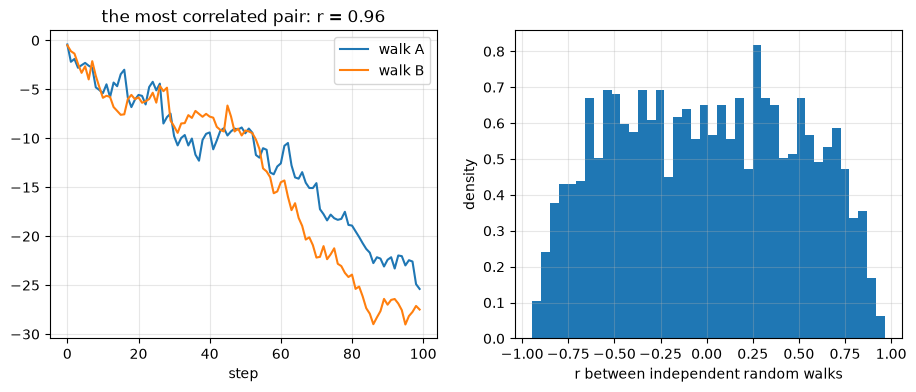

In [ ]:
n_steps, n_trials = 100, 2000
walks_a = np.cumsum(stats.norm().rvs((n_trials, n_steps), random_state=rng), axis=1)
walks_b = np.cumsum(stats.norm().rvs((n_trials, n_steps), random_state=rng), axis=1)

r = np.array([stats.pearsonr(a, b).statistic for a, b in zip(walks_a, walks_b)])
p = np.array([stats.pearsonr(a, b).pvalue for a, b in zip(walks_a, walks_b)])
print(f"independent random walks: |r| > 0.5 in {100*np.mean(np.abs(r) > 0.5):.0f}% of trials;  'significant' at 5% in {100*np.mean(p < 0.05):.0f}% of trials")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
i = np.argmax(np.abs(r))
ax[0].plot(walks_a[i], label="walk A"); ax[0].plot(walks_b[i], label="walk B")
ax[0].set(xlabel="step", title=f"the most correlated pair: r = {r[i]:.2f}"); ax[0].legend()
ax[1].hist(r, bins=40, density=True)
ax[1].set(xlabel="r between independent random walks", ylabel="density")
plt.show()

Correlations of $\pm 0.5$ or more between completely unrelated series are routine, and the p-value flags most pairs as significant. This is not a small effect. The standard remedies are to remove the trends first, or to correlate the year-to-year *changes* (first differences), which are much closer to independent.

Let us apply this to the two real series in the repository. Atmospheric CO₂ and global temperature both rise over 1959–2025, and are strongly correlated. The physics linking them is well established, but one should be clear that this correlation is *not* the evidence: the same $r$ would appear between CO₂ and anything else that trends. The correlation of the first differences is a fairer test of whether year-to-year changes go together.

levels:            r = 0.967, p = 2.4e-40  (p not to be trusted: trending series)
first differences: r = 0.319, p = 0.009


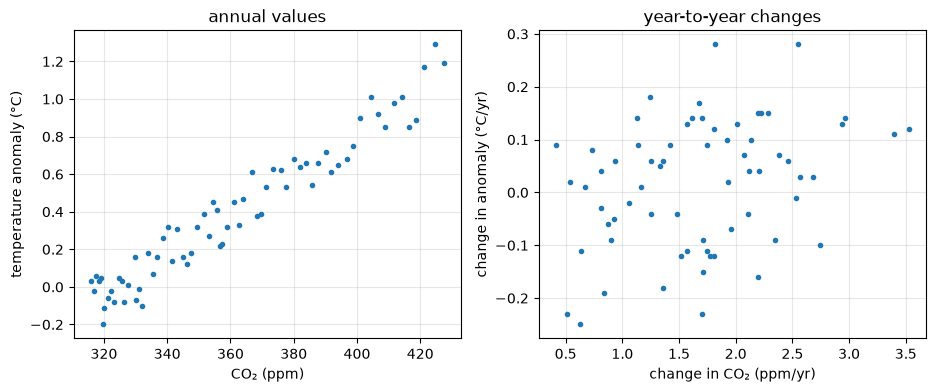

In [ ]:
co2 = pd.read_csv(DATA + "mauna_loa_co2_monthly.csv").groupby("year")["co2"].mean()
gis = pd.read_csv(DATA + "gistemp_global_annual.csv").set_index("year")["anomaly"]
both = pd.concat([co2, gis], axis=1, join="inner").loc[1959:2025]
c, T = both["co2"].to_numpy(), both["anomaly"].to_numpy()

r_level = stats.pearsonr(c, T)
r_diff = stats.pearsonr(np.diff(c), np.diff(T))
print(f"levels:            r = {r_level.statistic:.3f}, p = {r_level.pvalue:.1e}  (p not to be trusted: trending series)")
print(f"first differences: r = {r_diff.statistic:.3f}, p = {r_diff.pvalue:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(c, T, "o", ms=3); ax[0].set(xlabel="CO₂ (ppm)", ylabel="temperature anomaly (°C)", title="annual values")
ax[1].plot(np.diff(c), np.diff(T), "o", ms=3); ax[1].set(xlabel="change in CO₂ (ppm/yr)", ylabel="change in anomaly (°C/yr)", title="year-to-year changes")
plt.show()

The correlation of the changes is far weaker, about 0.3, though still detectable. The drop is not evidence against a causal link: the climate's response to CO₂ is slow, and from one year to the next it is swamped by El Niño and volcanic variability, so the interannual test has little power. But the comparison does show that the impressive $r$ of the levels carries little information by itself. Sorting out cause and effect here needs physics, not correlation coefficients.

### Regression to the mean

If you select the members of a group with the most extreme values of a noisy quantity and measure them again, the second measurements will on average be less extreme, simply because part of the first extreme value was noise that does not repeat. The wettest years are followed by drier ones, the worst-performing stations improve after the "intervention", the most anomalous samples look more ordinary on re-analysis. This is a statistical inevitability, not a physical effect, and it produces spurious "improvements" and "recoveries" whenever selection is based on the same noisy measurement.

mean of the selected sites: first measurement 2.46, second measurement 1.30


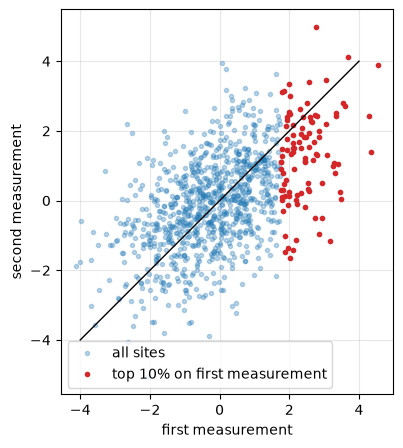

In [ ]:
true_value = stats.norm(0, 1).rvs(1000, random_state=rng)                 # each site has a true value
first = true_value + stats.norm(0, 1).rvs(1000, random_state=rng)         # first measurement: truth + noise
second = true_value + stats.norm(0, 1).rvs(1000, random_state=rng)        # second, independent noise
top = first > np.percentile(first, 90)                                    # select the 10% most extreme on the first measurement
print(f"mean of the selected sites: first measurement {first[top].mean():.2f}, second measurement {second[top].mean():.2f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(first, second, ".", alpha=0.3, label="all sites"); ax.plot(first[top], second[top], "C3.", label="top 10% on first measurement")
ax.plot([-4, 4], [-4, 4], "k", lw=1); ax.set(xlabel="first measurement", ylabel="second measurement", aspect="equal"); ax.legend()
plt.show()

### Errors in $x$ shrink the slope

The least-squares slope of $y$ on $x$ assumes $x$ is known exactly. If $x$ carries random error, the slope is biased towards zero by a factor $s_{x,\text{true}}^2 / (s_{x,\text{true}}^2 + \sigma_x^2)$, an effect called **regression dilution** or attenuation. The correlation coefficient is diluted in the same way. This is common in the Earth sciences, where the "independent" variable (an age, a depth, a temperature proxy) is often as uncertain as the dependent one. York's method (Notebook 5, Exercise 3) is one remedy; another is to correct the slope with the factor above if $\sigma_x$ is known.

In [ ]:
x_true = stats.uniform(0, 10).rvs(200, random_state=rng)
y_obs = 2*x_true + stats.norm(0, 2).rvs(200, random_state=rng)
for sigma_x in [0, 1, 2, 4]:
    x_obs = x_true + stats.norm(0, sigma_x).rvs(200, random_state=rng)
    lr = stats.linregress(x_obs, y_obs)
    factor = x_true.var() / (x_true.var() + sigma_x**2)
    print(f"σ_x = {sigma_x}: fitted slope = {lr.slope:.2f} ± {lr.stderr:.2f}  (true 2, expected dilution {2*factor:.2f}),  r = {lr.rvalue:.2f}")

σ_x = 0: fitted slope = 2.04 ± 0.05  (true 2, expected dilution 2.00),  r = 0.94
σ_x = 1: fitted slope = 1.78 ± 0.07  (true 2, expected dilution 1.78),  r = 0.88
σ_x = 2: fitted slope = 1.45 ± 0.08  (true 2, expected dilution 1.33),  r = 0.79
σ_x = 4: fitted slope = 0.59 ± 0.07  (true 2, expected dilution 0.67),  r = 0.50


## Summary

- Pearson's $r$ measures linear association; $r^2$ is the fraction of variance explained; the least-squares slope is $r s_y / s_x$.
- There are two regression lines; which one you want depends on which variable you are predicting.
- Always plot: Anscombe's quartet shows that identical statistics can describe utterly different data.
- Spearman's $\rho$ handles monotonic relationships and outliers.
- Correlation does not establish causation. Trending time series correlate spuriously and their p-values are meaningless; correlate the changes instead. Selection on noisy values produces regression to the mean. Errors in $x$ dilute the slope.

## Exercises

### Exercise 1

For Anscombe's set III, remove the outlier (the point with the largest residual from the fitted line) and refit. How much do $r$ and the slope change? Now compute Spearman's $\rho$ for set III with and without the outlier.

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
xa, ya = anscombe["III"]
lr = stats.linregress(xa, ya)
resid = ya - (lr.intercept + lr.slope*xa)
keep = np.abs(resid) < np.abs(resid).max()
lr2 = stats.linregress(xa[keep], ya[keep])
print(f"with outlier:    r = {lr.rvalue:.3f}, slope = {lr.slope:.3f}, Spearman ρ = {stats.spearmanr(xa, ya).statistic:.3f}")
print(f"without outlier: r = {lr2.rvalue:.3f}, slope = {lr2.slope:.3f}, Spearman ρ = {stats.spearmanr(xa[keep], ya[keep]).statistic:.3f}")
```

Without the outlier the ten remaining points lie exactly on a line ($r = 1$) with slope 0.345 rather than 0.5. Spearman's $\rho$ is 0.99 with the outlier and 1 without: the outlier has almost no effect on the rank correlation because it only moves one rank.

</details>

### Exercise 2

Repeat the random-walk experiment, but correlate the *first differences* of the two walks instead of the walks themselves. What fraction of trials is now "significant" at the 5% level? Why is this the right answer?

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
p_diff = np.array([stats.pearsonr(np.diff(a), np.diff(b)).pvalue for a, b in zip(walks_a, walks_b)])
print(f"first differences: significant at 5% in {100*np.mean(p_diff < 0.05):.1f}% of trials")
```

About 5%, which is exactly the Type I error rate a valid test should have. The first differences of a random walk are independent normal variables, so the assumptions of the test are met; the walks themselves are anything but independent from one step to the next.

</details>

### Exercise 3

The correlation between eruption duration and waiting time at Old Faithful was $r \approx 0.9$. Both clusters (short and long eruptions) contribute to this. Compute $r$ *within* each cluster separately (duration below and above 3 minutes). What do you find, and what does it tell you about how the overall correlation arises?

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
for name, mask in [("short eruptions", d < 3), ("long eruptions", d >= 3)]:
    r = stats.pearsonr(d[mask], w[mask])
    print(f"{name:16s}: n = {mask.sum():3d}, r = {r.statistic:.3f}, p = {r.pvalue:.1e}")
```

Within each cluster the correlation is modest (around 0.3 to 0.4). Most of the overall correlation comes from the *difference between the clusters*: short eruptions are followed by short waits, long by long. This is a version of the confounding problem: a variable that separates the data into groups (here, the type of eruption) can generate a strong overall correlation even when there is little relationship within groups. It is sometimes called Simpson's paradox when the within-group and between-group relationships have opposite signs.

</details>